In [197]:
import numpy as np 
import matplotlib.pyplot as plt 
from obspy import read_inventory, Inventory
from obspy.core import read, UTCDateTime, Stream
from obspy.clients.fdsn.client import Client
from obspy.geodetics import gps2dist_azimuth, locations2degrees
from obspy.signal.cross_correlation import correlate, xcorr_max
from obspy.signal import PPSD
from obspy.taup import TauPyModel
from glob import glob
import os

### Functions

In [198]:
def read_mseed(waveform_dir, network, station, location, channel, starttime, endtime, inv):
    """
    Reads mSEED files for a given station and time window.
    """
    st = Stream()

    if len(channel) == 1:
        file_pattern = os.path.join(waveform_dir, f"{network}.{station}.{location}")
        for file in glob(f"{file_pattern}.??{channel}__*.mseed"):
            st += read(file, starttime=starttime, endtime=endtime)
            st.remove_response(inventory=inv, output="VEL")
        return st
    else:
        file_pattern = os.path.join(waveform_dir, f"{network}.{station}.{location}.{channel}*.mseed")
        for file in glob(file_pattern):
            st += read(file, starttime=starttime, endtime=endtime)
            st.remove_response(inventory=inv, output="VEL")
        return st

def xml2inv(xml_dir):
    """
    Reads station inventory from XML files.
    """
    inv = Inventory()
    file_pattern = os.path.join(xml_dir, "*.xml")
    for file in glob(file_pattern):
        inv += read_inventory(file)
    return inv

### Load inventory and select stations

In [199]:
inv = xml2inv("/mckenzie/lyakuden/multiplet-data/2008/directivity/stations/")
model = TauPyModel(model="iasp91")

print(model.get_travel_times(source_depth_in_km=5,
                                       distance_in_degree=12,
                                       phase_list=["P", "S"]))

2 arrivals
	P phase arrival at 171.668 seconds
	S phase arrival at 307.140 seconds


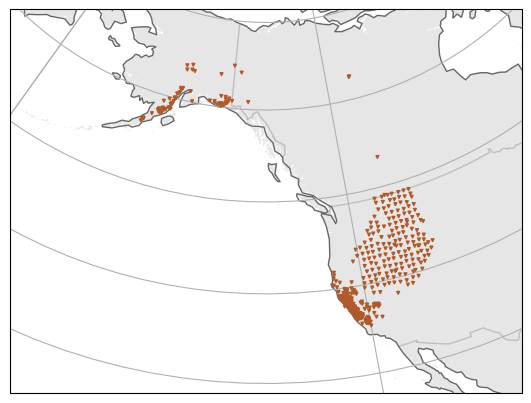

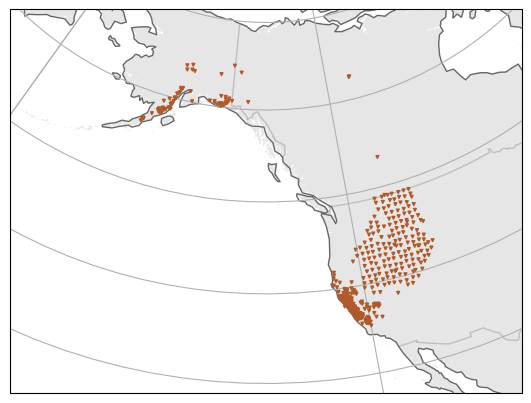

In [200]:
inv.plot("local",
         size=4,
         label=False)

# P wave

In [201]:
eq_coords = [51, -131]
dir_azims = [330, 150]
min_dist  = 11 # degrees
max_dist  = 13 # degrees
source_time = UTCDateTime("2008-01-05T11:01:00")

dir_stas  = []

for network in inv:
    for station in network:

        # distance filter
        event_station_distance = locations2degrees(eq_coords[0], eq_coords[1], station.latitude, station.longitude)
        if event_station_distance < min_dist or event_station_distance > max_dist:
            continue

        # travel time 
        p_arrival = model.get_travel_times(source_depth_in_km=5,
                                       distance_in_degree=event_station_distance,
                                       phase_list=["P"])[0].time

        # azimuth filter
        # azim is from event to station
        azim = gps2dist_azimuth(eq_coords[0], eq_coords[1], station.latitude, station.longitude)[1]
        for azimuth in dir_azims:
            if abs(azim - azimuth) < 15:
                # network code, station code, event-station azimuth in deg, distance in deg, P travel time in sec
                dir_stas.append((network.code, station.code, azim, event_station_distance, p_arrival))
        
print(len(dir_stas))

35


### Waveform fetching

In [202]:
st_north = Stream()
st_south = Stream()
remove_stations = ['NVE', 'GCK', 'GTS', 'OCR', 'GFC', 'GAR', 'GAC', 'GSS', 'GHO', 'GDC', 'AOH', 'GGU', 'GCVB', 'GBB', 'GMK', 'NPRB', 'GHG', 'GHC', 'GNA', 'NEH', 'BGLC']

for net, sta, azimuth, distance, p_ttime in dir_stas:

    if sta in remove_stations:
        continue

    # north networks
    if net == 'XZ' or net == 'AK' or net == 'AV':
    
        starttime = source_time + p_ttime - 30
        endtime   = source_time + p_ttime + 30

        st_north += read_mseed("/mckenzie/lyakuden/multiplet-data/2008/directivity/waveforms/", net, sta, "*", "Z", starttime, endtime, inv)

    # south networks
    if net ==  'NC' or net == 'TA':

        starttime = source_time + p_ttime - 30
        endtime   = source_time + p_ttime + 30

        st_south += read_mseed("/mckenzie/lyakuden/multiplet-data/2008/directivity/waveforms/", net, sta, "*", "Z", starttime, endtime, inv)

print(len(st_north))
print(len(st_south))

17
13


 WARNING (norm_resp): computed and reported sensitivities differ by more than 5 percent. 
	 Execution continuing.


### Filter waveforms

In [203]:
# resample all to 100 Hz
st_north.resample(100)
st_south.resample(100)

# filter
st_north.filter("bandpass", freqmin=0.6, freqmax=8.0)
st_south.filter("bandpass", freqmin=0.6, freqmax=8.0)

# taper
st_north.taper(max_percentage=0.3, type="cosine")
st_south.taper(max_percentage=0.3, type="cosine")

13 Trace(s) in Stream:
NC.GRO..EHZ  | 2008-01-05T11:03:28.640000Z - 2008-01-05T11:04:28.640000Z | 100.0 Hz, 6001 samples
NC.GHM..EHZ  | 2008-01-05T11:03:32.769900Z - 2008-01-05T11:04:32.769900Z | 100.0 Hz, 6001 samples
TA.M07A..BHZ | 2008-01-05T11:03:29.799998Z - 2008-01-05T11:04:29.809998Z | 100.0 Hz, 6002 samples
NC.GWR..EHZ  | 2008-01-05T11:03:34.909900Z - 2008-01-05T11:04:34.909900Z | 100.0 Hz, 6001 samples
NC.KCT..HHZ  | 2008-01-05T11:03:14.747700Z - 2008-01-05T11:04:14.747700Z | 100.0 Hz, 6001 samples
NC.KHMB..HHZ | 2008-01-05T11:03:12.135700Z - 2008-01-05T11:04:12.135700Z | 100.0 Hz, 6001 samples
NC.KHBB..HHZ | 2008-01-05T11:03:17.017700Z - 2008-01-05T11:04:17.017700Z | 100.0 Hz, 6001 samples
NC.KMPB..HHZ | 2008-01-05T11:03:16.327700Z - 2008-01-05T11:04:16.327700Z | 100.0 Hz, 6001 samples
NC.KMR..HHZ  | 2008-01-05T11:03:20.687700Z - 2008-01-05T11:04:20.687700Z | 100.0 Hz, 6001 samples
NC.GVV..EHZ  | 2008-01-05T11:03:30.380000Z - 2008-01-05T11:04:30.380000Z | 100.0 Hz, 6001 sampl

### Cross-correlate waveforms for alignmnet

- 1st cell correlates based on a good waveform from the traces
- 2nd cell correlates using the stacked waveform as the reference, drawing from the original traces (reset sampling)

In [204]:
north_reference = st_north[0]
south_reference = st_south[3]

north_stack = []
south_stack = []

north_stack_stations = []
south_stack_stations = []

for tr in st_north:

    # use onset as window
    tr1 = north_reference.copy().data[3400:4100]
    tr2 = tr.copy().data[3400:4100]

    cc = correlate(tr1, tr2, 1000)
    shift, value = xcorr_max(cc)

    if value < 0.6:
        continue

    shifted_trace = np.roll(tr.data, shift)

    north_stack.append(shifted_trace)
    north_stack_stations.append(tr.stats.station)

for tr in st_south:
    
        # use onset as window
        tr1 = south_reference.copy().data[4000:5000]
        tr2 = tr.copy().data[4000:5000]
    
        cc = correlate(tr1, tr2, 1000)
        shift, value = xcorr_max(cc)

        if value < 0.6:
            continue
    
        shifted_trace = np.roll(tr.data, shift)
    
        south_stack.append(shifted_trace)
        south_stack_stations.append(tr.stats.station)

# ensure same length of traces
min_length_north = min([len(tr) for tr in north_stack])
min_length_south = min([len(tr) for tr in south_stack])
north_stack = [tr[:min_length_north] for tr in north_stack]
south_stack = [tr[:min_length_south] for tr in south_stack]

print(len(north_stack))
print(len(south_stack))


14
8


In [205]:
for array in south_stack:
    print(len(array))

6001
6001
6001
6001
6001
6001
6001
6001


In [206]:
north_stacked = np.sum(np.array(north_stack), axis=0) / len(north_stack)
south_stacked = np.sum(np.array(south_stack), axis=0) / len(south_stack)

north_stack = []
south_stack = []

north_stack_stations = []
south_stack_stations = []

for tr in st_north:

    # use onset as window
    tr1 = north_stacked.copy().data[3200:3800]
    tr2 = tr.copy().data[3200:3800]

    cc = correlate(tr1, tr2, 1000)
    shift, value = xcorr_max(cc)

    # if value < 0.6:
    #     continue

    shifted_trace = np.roll(tr.data, shift)

    north_stack.append(shifted_trace)
    north_stack_stations.append(tr.stats.station)

for tr in st_south:
    
        # use onset as window
        tr1 = south_stacked.copy().data[4000:5000]
        tr2 = tr.copy().data[4000:5000]
    
        cc = correlate(tr1, tr2, 1000)
        shift, value = xcorr_max(cc)

        # if value < 0.6:
        #     continue
    
        shifted_trace = np.roll(tr.data, shift)
    
        south_stack.append(shifted_trace)
        south_stack_stations.append(tr.stats.station)

# ensure same length of traces
min_length_north = min([len(tr) for tr in north_stack])
min_length_south = min([len(tr) for tr in south_stack])
north_stack = [tr[:min_length_north] for tr in north_stack]
south_stack = [tr[:min_length_south] for tr in south_stack]


for array in south_stack:
    print(len(array))

print(len(north_stack))
print(len(south_stack))

6001
6001
6001
6001
6001
6001
6001
6001
6001
6001
6001
6001
6001
17
13


### Plot stacks

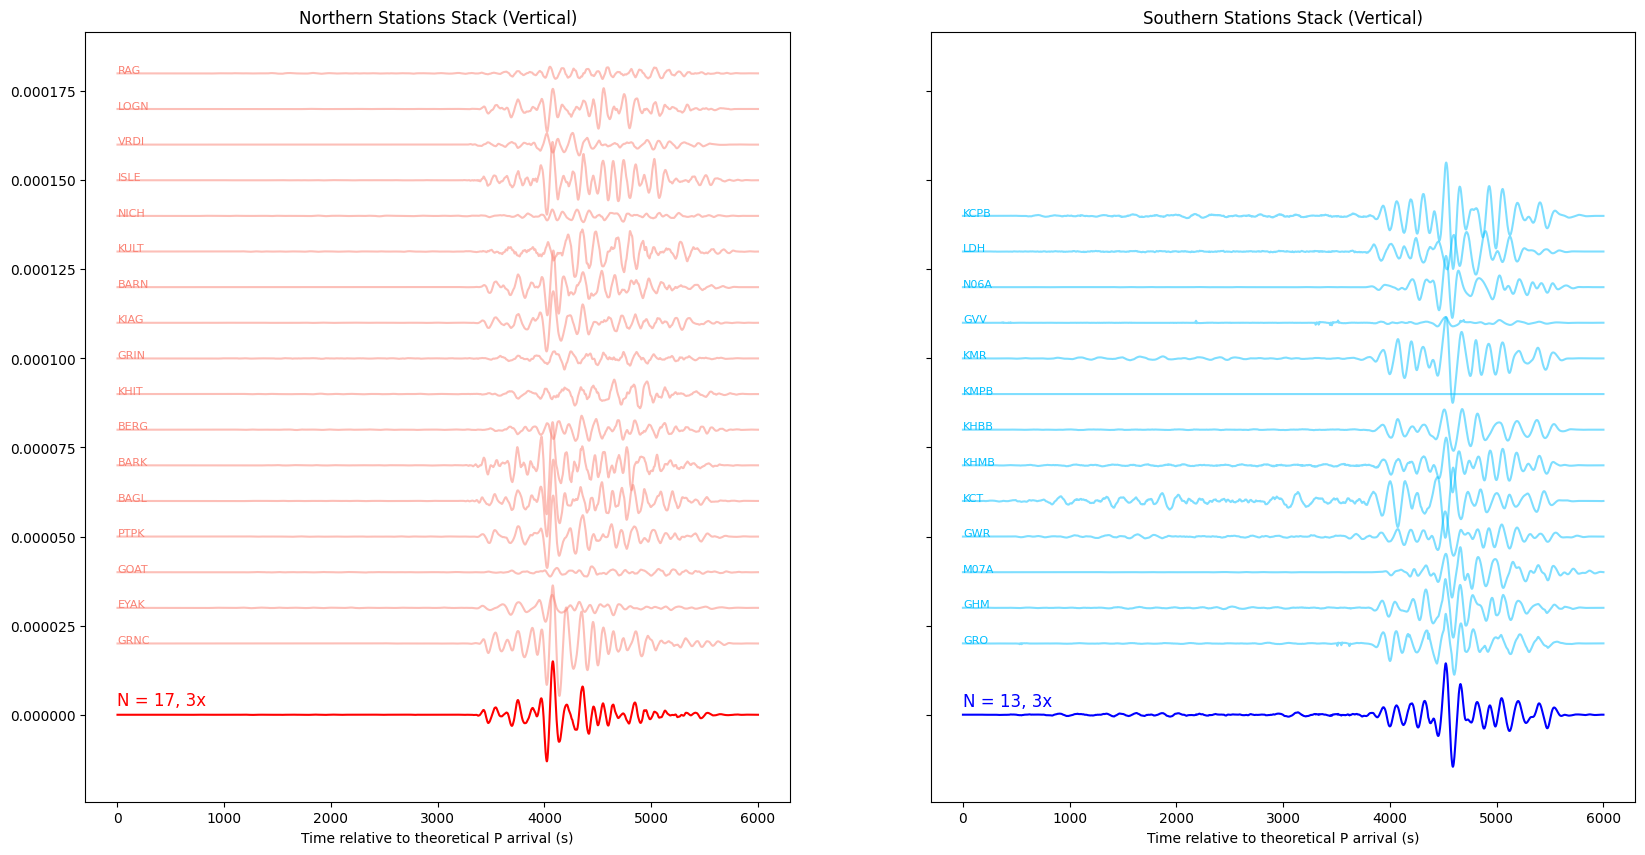

In [207]:
# calculate stacked waveforms
north_stacked = np.sum(np.array(north_stack), axis=0) / len(north_stack)
south_stacked = np.sum(np.array(south_stack), axis=0) / len(south_stack)

# initialize figure
fig, ax = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

# individual trace offsets
trace_offset = np.maximum(np.max(north_stacked), np.max(south_stacked)) * 2

# northern stack 
ax[0].plot(north_stacked * 3, color='red')
ax[0].text(0, 0.5 * np.max(north_stacked), f"N = {len(north_stack)}, 3x", fontsize=12, color='red')
ax[0].set_title("Northern Stations Stack (Vertical)")

# individual traces
for i, trace in enumerate(north_stack):
    ax[0].plot(trace + (i + 2) * trace_offset, color='salmon', alpha=0.5, zorder=1)
    ax[0].text(0, (i + 2) * trace_offset, f"{north_stack_stations[i]}", fontsize=8, color='salmon')

# southern stack
ax[1].plot(south_stacked * 3, color='blue')
ax[1].text(0, 0.5 * np.max(south_stacked), f"N = {len(south_stack)}, 3x", fontsize=12, color='blue')
ax[1].set_title("Southern Stations Stack (Vertical)")

# individual traces
for i, trace in enumerate(south_stack):
    ax[1].plot(trace + (i + 2) * trace_offset, color='deepskyblue', alpha=0.5, zorder=1)
    ax[1].text(0, (i + 2) * trace_offset, f"{south_stack_stations[i]}", fontsize=8, color='deepskyblue')

for axis in ax:
    
    # make x-axis in seconds assuming 100 Hz 
    x_ticks = axis.get_xticks()
    x_tick_labels = [f"{int(tick / 100) - 30}" for tick in x_ticks]
    # axis.set_xticklabels(x_tick_labels)

    axis.set_xlabel("Time relative to theoretical P arrival (s)")

# plt.savefig("../figures/directivity_p_stacks.png", dpi=300, bbox_inches='tight')

# S wave

In [10]:
eq_coords = [51, -131]
dir_azims = [330, 150]
min_dist  = 11 # degrees
max_dist  = 13 # degrees
source_time = UTCDateTime("2008-01-05T11:01:00")

dir_stas  = []

for network in inv:
    for station in network:

        # distance filter
        event_station_distance = locations2degrees(eq_coords[0], eq_coords[1], station.latitude, station.longitude)
        if event_station_distance < min_dist or event_station_distance > max_dist:
            continue

        # travel time 
        s_arrival = model.get_travel_times(source_depth_in_km=5,
                                       distance_in_degree=event_station_distance,
                                       phase_list=["S"])[0].time

        # azimuth filter
        # azim is from event to station
        bazim = gps2dist_azimuth(eq_coords[0], eq_coords[1], station.latitude, station.longitude)[2]
        for azimuth in dir_azims:
            if abs(bazim - azimuth) < 15:
                # network code, station code, event-station azimuth in deg, distance in deg, P travel time in sec
                dir_stas.append((network.code, station.code, bazim, event_station_distance, s_arrival))
        
print(len(dir_stas))


31


In [11]:
st_north = Stream()
st_south = Stream()
remove_stations = []# ['NVE', 'GCK', 'GTS', 'OCR', 'GFC', 'GAR', 'GAC', 'GSS', 'GHO', 'GDC', 'AOH', 'GGU', 'GCVB', 'GBB', 'GMK', 'NPRB', 'GHG', 'GHC', 'GNA', 'NEH', 'BGLC']

for net, sta, bazimuth, distance, s_ttime in dir_stas:
    temp_st = Stream()

    if sta in remove_stations:
        continue

    # north networks
    if net == 'XZ' or net == 'AK':
    
        starttime = source_time + s_ttime - 60
        endtime   = source_time + s_ttime + 60

        temp_st += read_mseed("/mckenzie/lyakuden/multiplet-data/2008/directivity/waveforms/", net, sta, "*", "E", starttime, endtime, inv)
        temp_st += read_mseed("/mckenzie/lyakuden/multiplet-data/2008/directivity/waveforms/", net, sta, "*", "N", starttime, endtime, inv)
        temp_st.rotate(method='NE->RT', back_azimuth=bazimuth, inventory=inv)
        st_north += temp_st.select(component="T")

    # south networks
    if net ==  'NC' or net == 'TA':

        starttime = source_time + s_ttime - 60
        endtime   = source_time + s_ttime + 60

        temp_st += read_mseed("/mckenzie/lyakuden/multiplet-data/2008/directivity/waveforms/", net, sta, "*", "E", starttime, endtime, inv)
        temp_st += read_mseed("/mckenzie/lyakuden/multiplet-data/2008/directivity/waveforms/", net, sta, "*", "N", starttime, endtime, inv)
        temp_st.rotate(method='NE->RT', back_azimuth=bazimuth, inventory=inv)
        st_south += temp_st.select(component="T")

print(len(st_south))
print(st_south)

 WARNING (norm_resp): computed and reported sensitivities differ by more than 5 percent. 
	 Execution continuing.
 WARNING (norm_resp): computed and reported sensitivities differ by more than 5 percent. 
	 Execution continuing.


7
7 Trace(s) in Stream:
NC.KCT..HHT  | 2008-01-05T11:04:54.757700Z - 2008-01-05T11:06:54.757700Z | 100.0 Hz, 12001 samples
NC.KHMB..HHT | 2008-01-05T11:04:50.085700Z - 2008-01-05T11:06:50.085700Z | 100.0 Hz, 12001 samples
NC.KHBB..HHT | 2008-01-05T11:04:58.807700Z - 2008-01-05T11:06:58.807700Z | 100.0 Hz, 12001 samples
NC.KMPB..HHT | 2008-01-05T11:04:57.587700Z - 2008-01-05T11:06:57.587700Z | 100.0 Hz, 12001 samples
NC.KMR..HHT  | 2008-01-05T11:05:05.377700Z - 2008-01-05T11:07:05.377700Z | 100.0 Hz, 12001 samples
NC.LDH..HHT  | 2008-01-05T11:05:15.807700Z - 2008-01-05T11:07:15.807700Z | 100.0 Hz, 12001 samples
NC.KCPB..HHT | 2008-01-05T11:05:17.947700Z - 2008-01-05T11:07:17.947700Z | 100.0 Hz, 12001 samples


In [12]:
# resample all to 100 Hz
st_north.resample(100)
st_south.resample(100)

# filter
st_north.filter("bandpass", freqmin=0.01, freqmax=5.0)
st_south.filter("bandpass", freqmin=0.01, freqmax=5.0)

# taper
st_north.taper(max_percentage=0.3, type="cosine")
st_south.taper(max_percentage=0.3, type="cosine")

7 Trace(s) in Stream:
NC.KCT..HHT  | 2008-01-05T11:04:54.757700Z - 2008-01-05T11:06:54.757700Z | 100.0 Hz, 12001 samples
NC.KHMB..HHT | 2008-01-05T11:04:50.085700Z - 2008-01-05T11:06:50.085700Z | 100.0 Hz, 12001 samples
NC.KHBB..HHT | 2008-01-05T11:04:58.807700Z - 2008-01-05T11:06:58.807700Z | 100.0 Hz, 12001 samples
NC.KMPB..HHT | 2008-01-05T11:04:57.587700Z - 2008-01-05T11:06:57.587700Z | 100.0 Hz, 12001 samples
NC.KMR..HHT  | 2008-01-05T11:05:05.377700Z - 2008-01-05T11:07:05.377700Z | 100.0 Hz, 12001 samples
NC.LDH..HHT  | 2008-01-05T11:05:15.807700Z - 2008-01-05T11:07:15.807700Z | 100.0 Hz, 12001 samples
NC.KCPB..HHT | 2008-01-05T11:05:17.947700Z - 2008-01-05T11:07:17.947700Z | 100.0 Hz, 12001 samples

In [13]:
north_reference = st_north[3]
south_reference = st_south[1]

north_stack = []
south_stack = []

north_stack_stations = []
south_stack_stations = []

for tr in st_north:

    # use onset as window
    tr1 = north_reference.copy().data[3000:8000]
    tr2 = tr.copy().data[3000:8000]

    cc = correlate(tr1, tr2, 1000)
    shift, value = xcorr_max(cc)

    if value < 0.1:
        continue

    shifted_trace = np.roll(tr.data, shift)

    north_stack.append(shifted_trace)
    north_stack_stations.append(tr.stats.station)

for tr in st_south:
    
        # use onset as window
        tr1 = south_reference.copy().data[3000:8000]
        tr2 = tr.copy().data[3000:8000]
    
        cc = correlate(tr1, tr2, 1000)
        shift, value = xcorr_max(cc)

        # if value < 0.1:
        #     continue

        print(shift, value)
        shifted_trace = np.roll(tr.data, shift)
    
        south_stack.append(shifted_trace)
        south_stack_stations.append(tr.stats.station)

print(len(north_stack))
print(len(south_stack))


120 0.41705839723668203
0 1.0000000000000004
34 0.6863664951971292
-1000 0.0
-209 0.5057572908592156
83 0.5605936311685299
-212 0.7321946778170445
15
7


/tmp/ipykernel_446711/2703199238.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(x_tick_labels)
/tmp/ipykernel_446711/2703199238.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(x_tick_labels)


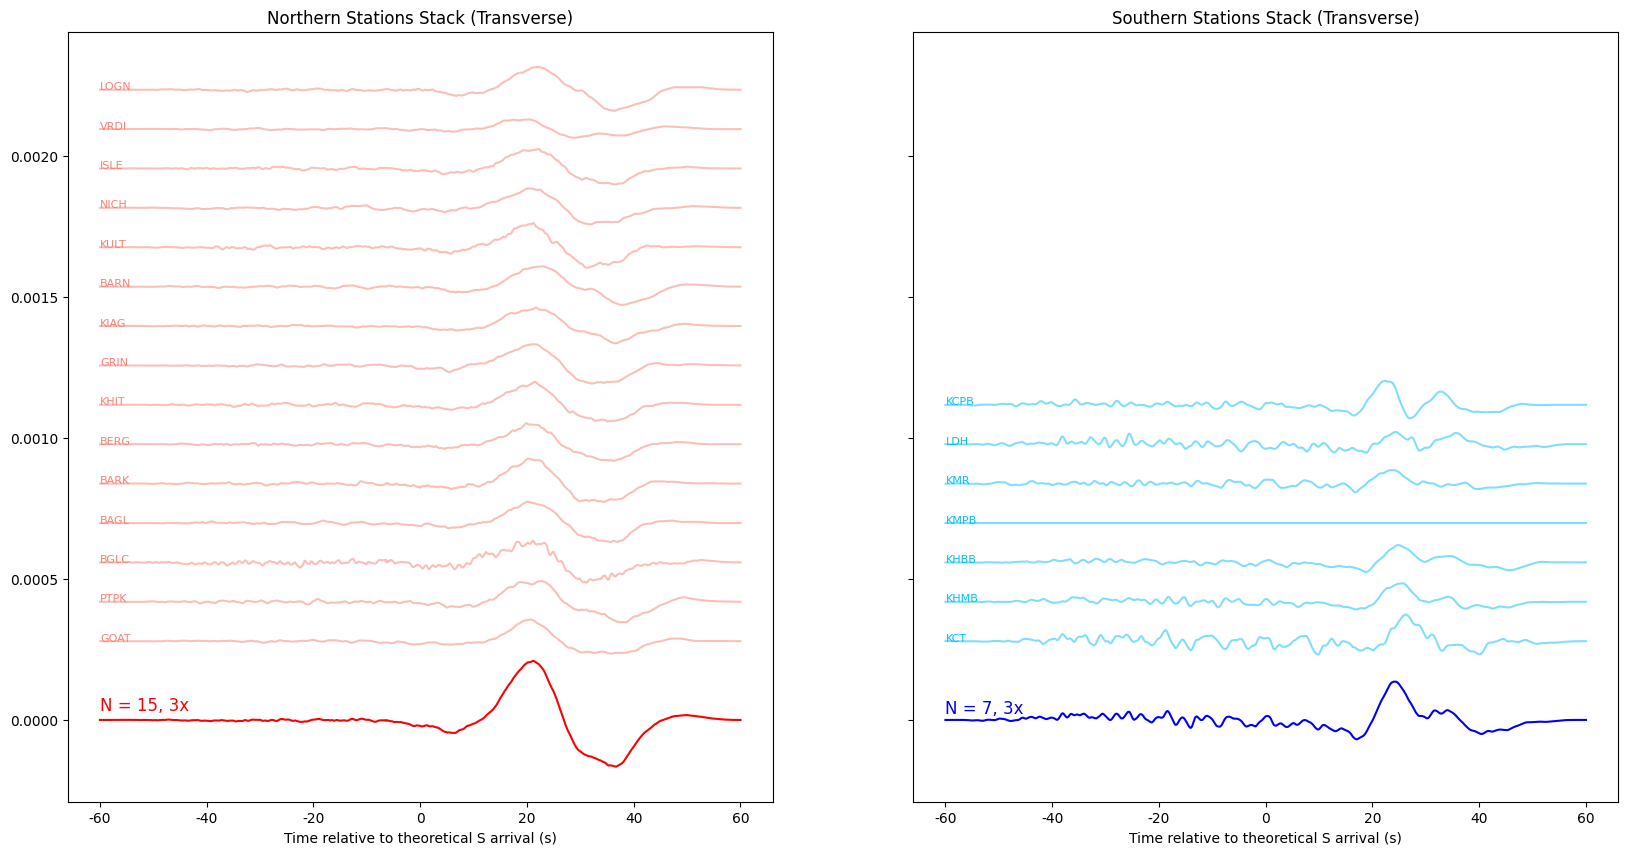

In [14]:
# calculate stacked waveforms
north_stacked = np.sum(np.array(north_stack), axis=0) / len(north_stack)
south_stacked = np.sum(np.array(south_stack), axis=0) / len(south_stack)

# initialize figure
fig, ax = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

# individual trace offsets
trace_offset = np.maximum(np.max(north_stacked), np.max(south_stacked)) * 2

# northern stack 
ax[0].plot(north_stacked * 3, color='red')
ax[0].text(0, 0.5 * np.max(north_stacked), f"N = {len(north_stack)}, 3x", fontsize=12, color='red')
ax[0].set_title("Northern Stations Stack (Transverse)")

# individual traces
for i, trace in enumerate(north_stack):
    ax[0].plot(trace + (i + 2) * trace_offset, color='salmon', alpha=0.5, zorder=1)
    ax[0].text(0, (i + 2) * trace_offset, f"{north_stack_stations[i]}", fontsize=8, color='salmon')

# southern stack
ax[1].plot(south_stacked * 3, color='blue')
ax[1].text(0, 0.5 * np.max(south_stacked), f"N = {len(south_stack)}, 3x", fontsize=12, color='blue')
ax[1].set_title("Southern Stations Stack (Transverse)")

# individual traces
for i, trace in enumerate(south_stack):
    ax[1].plot(trace + (i + 2) * trace_offset, color='deepskyblue', alpha=0.5, zorder=1)
    ax[1].text(0, (i + 2) * trace_offset, f"{south_stack_stations[i]}", fontsize=8, color='deepskyblue')

for axis in ax:
    
    # make x-axis in seconds assuming 100 Hz 
    x_ticks = axis.get_xticks()
    x_tick_labels = [f"{int(tick / 100) - 60}" for tick in x_ticks]
    axis.set_xticklabels(x_tick_labels)

    axis.set_xlabel("Time relative to theoretical S arrival (s)")

plt.savefig("../figures/directivity_s_stacks.png", dpi=300, bbox_inches='tight')

# Azimuthal variation

In [119]:
eq_coords = [51, -131]
dir_azims = [330, 150]
min_dist  = 13 # degrees
max_dist  = 17 # degrees
source_time = UTCDateTime("2008-01-05T11:01:00")

station_list = []

for network in inv:
    for station in network:

        # station filter
        if station.code in remove_stations:
            continue 

        # distance filter
        event_station_distance = locations2degrees(eq_coords[0], eq_coords[1], station.latitude, station.longitude)
        if event_station_distance < min_dist or event_station_distance > max_dist:
            continue

        # travel time 
        s_arrival = model.get_travel_times(source_depth_in_km=5,
                                       distance_in_degree=event_station_distance,
                                       phase_list=["S"])[0].time
        
        p_arrival = model.get_travel_times(source_depth_in_km=5,
                                        distance_in_degree=event_station_distance,
                                        phase_list=["P"])[0].time
        
        # s_arrival = 90

        # azim is from event to station
        azim  = gps2dist_azimuth(eq_coords[0], eq_coords[1], station.latitude, station.longitude)[1]
        bazim = gps2dist_azimuth(eq_coords[0], eq_coords[1], station.latitude, station.longitude)[2]

        # fetch waveforms and rotate to transverse
        temp_st = Stream()

        starttime = source_time + s_arrival - 30
        endtime   = source_time + s_arrival + 30

        try:
            temp_st += read_mseed("/mckenzie/lyakuden/multiplet-data/2008/directivity/waveforms/", network.code, station.code, "*", "E", starttime, endtime, inv)
            temp_st += read_mseed("/mckenzie/lyakuden/multiplet-data/2008/directivity/waveforms/", network.code, station.code, "*", "N", starttime, endtime, inv)
            temp_st.rotate(method='NE->RT', back_azimuth=azim, inventory=inv)
            transverse_trace = temp_st.select(component="T")[0]

            # temp_st += read_mseed("/mckenzie/lyakuden/multiplet-data/2008/directivity/waveforms/", network.code, station.code, "*", "Z", starttime, endtime, inv)
            # transverse_trace = temp_st.select(component="Z")[0]

            # network code, station code, transverse data as array, event-station azimuth, event-station distance in deg
            station_list.append((network.code, station.code, transverse_trace.data, azim, event_station_distance))

        except:
            continue
            
        
print(len(station_list))

 WARNING (norm_resp): computed and reported sensitivities differ by more than 5 percent. 
	 Execution continuing.
 WARNING (norm_resp): computed and reported sensitivities differ by more than 5 percent. 
	 Execution continuing.


127


In [120]:
# find number of occurences of "TA" in first element of each tuple
ta_count = sum(1 for station in station_list if station[0] == 'TA')
print(f"Number of TA stations: {ta_count}")

Number of TA stations: 95


## EXPAND OUT TO 16 DEGREES FOR ALASKAN PANHANDLE AK STATIONS

Text(0.5, 0, 'Azimuth (deg)')

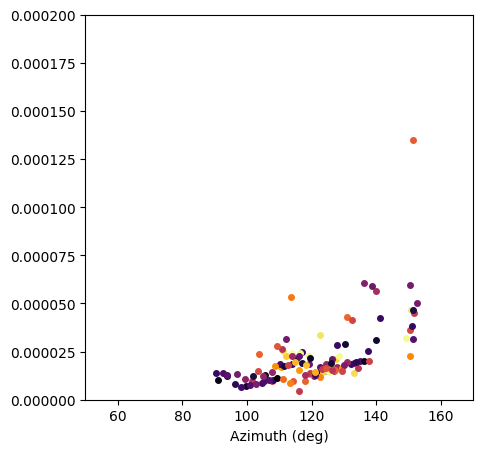

In [128]:
fig, ax = plt.subplots(figsize=(5, 5))

# make colormap for distance
distances_range = [min_dist, max_dist]
cmap = plt.get_cmap('inferno')

for net, sta, tr_data, azim, distance in station_list:
    # get color based on distance
    distance_normalized = (distance - distances_range[0]) / (distances_range[1] - distances_range[0])
    distance = cmap(distance_normalized)

    ax.plot(azim, np.max(np.abs(tr_data)), marker='o', markersize=4, label=f"{sta} ({net})", c=distance)


# plt.yscale('log')
plt.ylim(0, 0.0002)
plt.xlim(50, 170)
plt.xlabel("Azimuth (deg)")

[-31.2085 -11.1655  11.1655  33.2975] [  8.62   -0.397 -22.896   0.397]


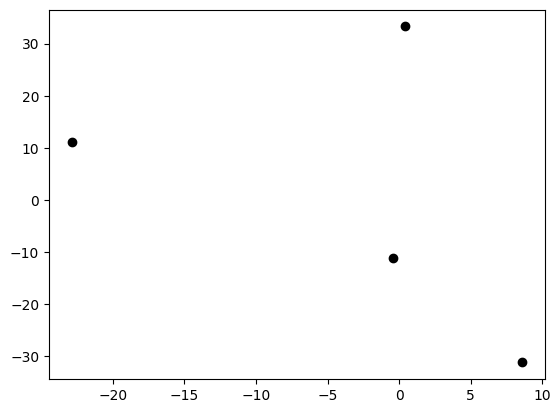

In [213]:
northing = np.array([5638938, 5658981, 5681312, 5703444]) / 1000 - np.median(np.array([5638938, 5658981, 5681312, 5703444]) / 1000)
easting  = np.array([364064, 355047, 332548, 355841]) / 1000 - np.median(np.array([364064, 355047, 332548, 355841]) / 1000)

print(northing, easting)

plt.scatter(easting, northing, c='black')